In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
np.random.seed(17)

Util-функции

In [2]:
@dataclass
class Plot:
    x: list
    y: list
    label: str = None
    color: str = None
    linewidth: float = 1.0
    linestyle: str = "-"
    marker: str = None
    markersize: float = None
    markerevery: float = None

class Plot_Group:
    def __init__(
            self, title: str | None = None, x_label: str | None = None, y_label: str | None = None,
            legend: bool = False, legend_loc: str | None = "best", legend_fontsize: str | None = "small",
            grid: bool = True, xlim: tuple | None = None, ylim: tuple | None = None
        ):
        self.title = title
        self.x_label = x_label
        self.y_label = y_label
        self.legend = legend
        self.legend_loc = legend_loc
        self.legend_fontsize = legend_fontsize
        self.grid = grid
        self.xlim = xlim
        self.ylim = ylim
        self.plots = list()

    def add_plot(self, Plot):
        self.plots.append(Plot)

class Chart:
    def __init__(self, rows: int = 1, cols: int = 1, width: float = 7, height: float = 5):
        self.rows = rows
        self.cols = cols
        self.width = width
        self.height = height
        self.__cur_ij = [0, 0]
        self.__plot_groups = [[None for _ in range(self.cols)] for _ in range(self.rows)]

    def add_plot_group(self, Plot_Group: Plot_Group, ij: list = None):
        if ij is None:
            if self.__cur_ij[0] >= self.rows:
                raise IndexError("Max quantity of plots achieved!")
            ij = self.__cur_ij
        while self.__plot_groups[self.__cur_ij[0]][self.__cur_ij[1]] is not None:
            self.__cur_ij[1] += 1
            if self.__cur_ij[1] >= self.cols:
                self.__cur_ij[1] = 0
                self.__cur_ij[0] += 1
        self.__plot_groups[ij[0]][ij[1]] = Plot_Group

    def __make_chart(self):
        fig, axes = plt.subplots(self.rows, self.cols, figsize=(self.width, self.height))
        if self.rows == 1 and self.cols == 1:
            axes = [[axes]]
        elif self.rows == 1:
            axes = [axes]
        elif self.cols == 1:
            axes = [[ax] for ax in axes]

        for i in range(self.rows):
            for j in range(self.cols):
                plot_group_ij = self.__plot_groups[i][j]
                if plot_group_ij is None: 
                    fig.delaxes(axes[i][j])
                    continue
                
                if plot_group_ij.title:
                    axes[i][j].set_title(plot_group_ij.title)
                if plot_group_ij.x_label:
                    axes[i][j].set_xlabel(plot_group_ij.x_label)
                if plot_group_ij.y_label:
                    axes[i][j].set_ylabel(plot_group_ij.y_label)
                for plot in plot_group_ij.plots:
                    axes[i][j].plot(
                        plot.x, plot.y,
                        label=plot.label,
                        color=plot.color,
                        linewidth=plot.linewidth,
                        linestyle=plot.linestyle,
                        marker=plot.marker,
                        markersize=plot.markersize,
                        markevery=plot.markerevery
                    )
                if plot_group_ij.legend and any(plot.label for plot in plot_group_ij.plots):
                    axes[i][j].legend(loc=plot_group_ij.legend_loc, fontsize=plot_group_ij.legend_fontsize)

                if plot_group_ij.xlim is not None:
                    axes[i][j].set_xlim(plot_group_ij.xlim[0], plot_group_ij.xlim[1])
                if plot_group_ij.ylim is not None:
                    axes[i][j].set_ylim(plot_group_ij.ylim[0], plot_group_ij.ylim[1])

                if plot_group_ij.grid: axes[i][j].grid(True)
                else: axes[i][j].grid(False)

        plt.gca().set_axisbelow(True) 
        plt.tight_layout()

    def draw_chart(self):
        self.__make_chart()
        plt.show()

    def save_chart(self, folder_path:str = "", filename:str = "chart", dpi="figure"):
        self.__make_chart()
        plt.savefig(folder_path+filename+".png", dpi=dpi)

In [3]:
def list_func(func):
    def wrapper(x_lst):
        result = []
        for x in x_lst:
            result.append(func(x))
        return result
    return wrapper

In [4]:
plt_folder = "plots/"

# Задание 1

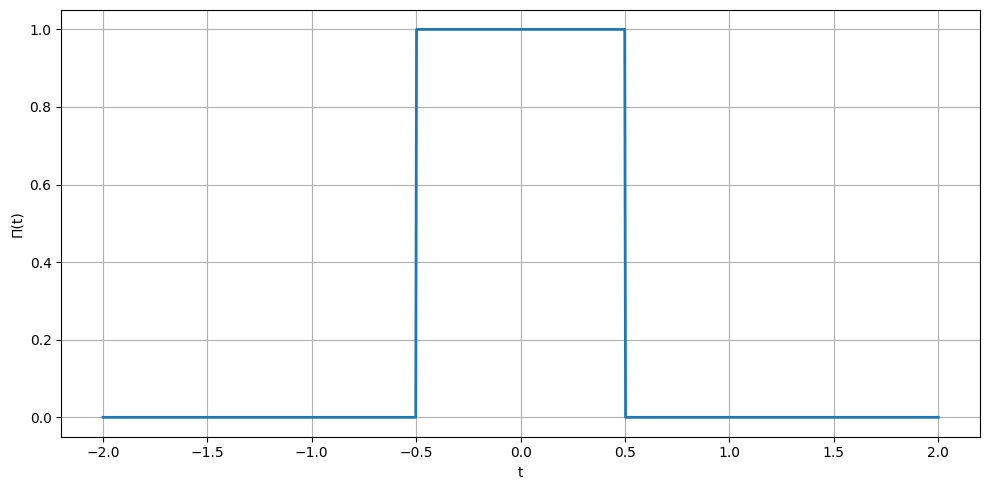

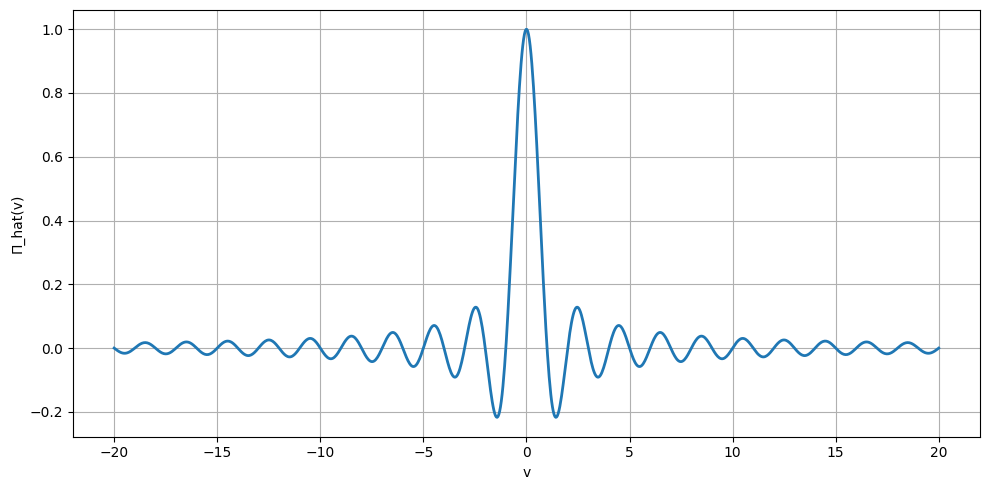

In [5]:
@list_func
def rect_func(t):
    if np.abs(t) <= 0.5: return 1
    else: return 0

@list_func
def sinc(v):
    return np.sin(np.pi * v) / (np.pi * v)

t_rect = np.linspace(-2.0, 2.0, 1000)
v_rect = np.linspace(-20.0, 20.0, 1000)

PI = rect_func(t_rect)
PI_hat = sinc(v_rect)

plt_g = Plot_Group(x_label="t", y_label="П(t)")
plt_g.add_plot(Plot(t_rect, PI, linewidth=2))
chart = Chart(width=10)
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "П(t)", dpi=700)
del plt_g, chart

plt_g = Plot_Group(x_label="v", y_label="П_hat(v)")
plt_g.add_plot(Plot(v_rect, PI_hat, linewidth=2))
chart = Chart(width=10)
chart.add_plot_group(plt_g)
chart.save_chart(plt_folder, "П_hat(v)", dpi=700)
del plt_g, chart

# Задание 1.1

In [6]:
t_rect = np.arange(-10.0, 10.0001, 0.0001)
v_rect = np.arange(-25.0, 25.0001, 0.0001)

PI = rect_func(t_rect)
PI_hat = sinc(v_rect)

/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ns/ros2_venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


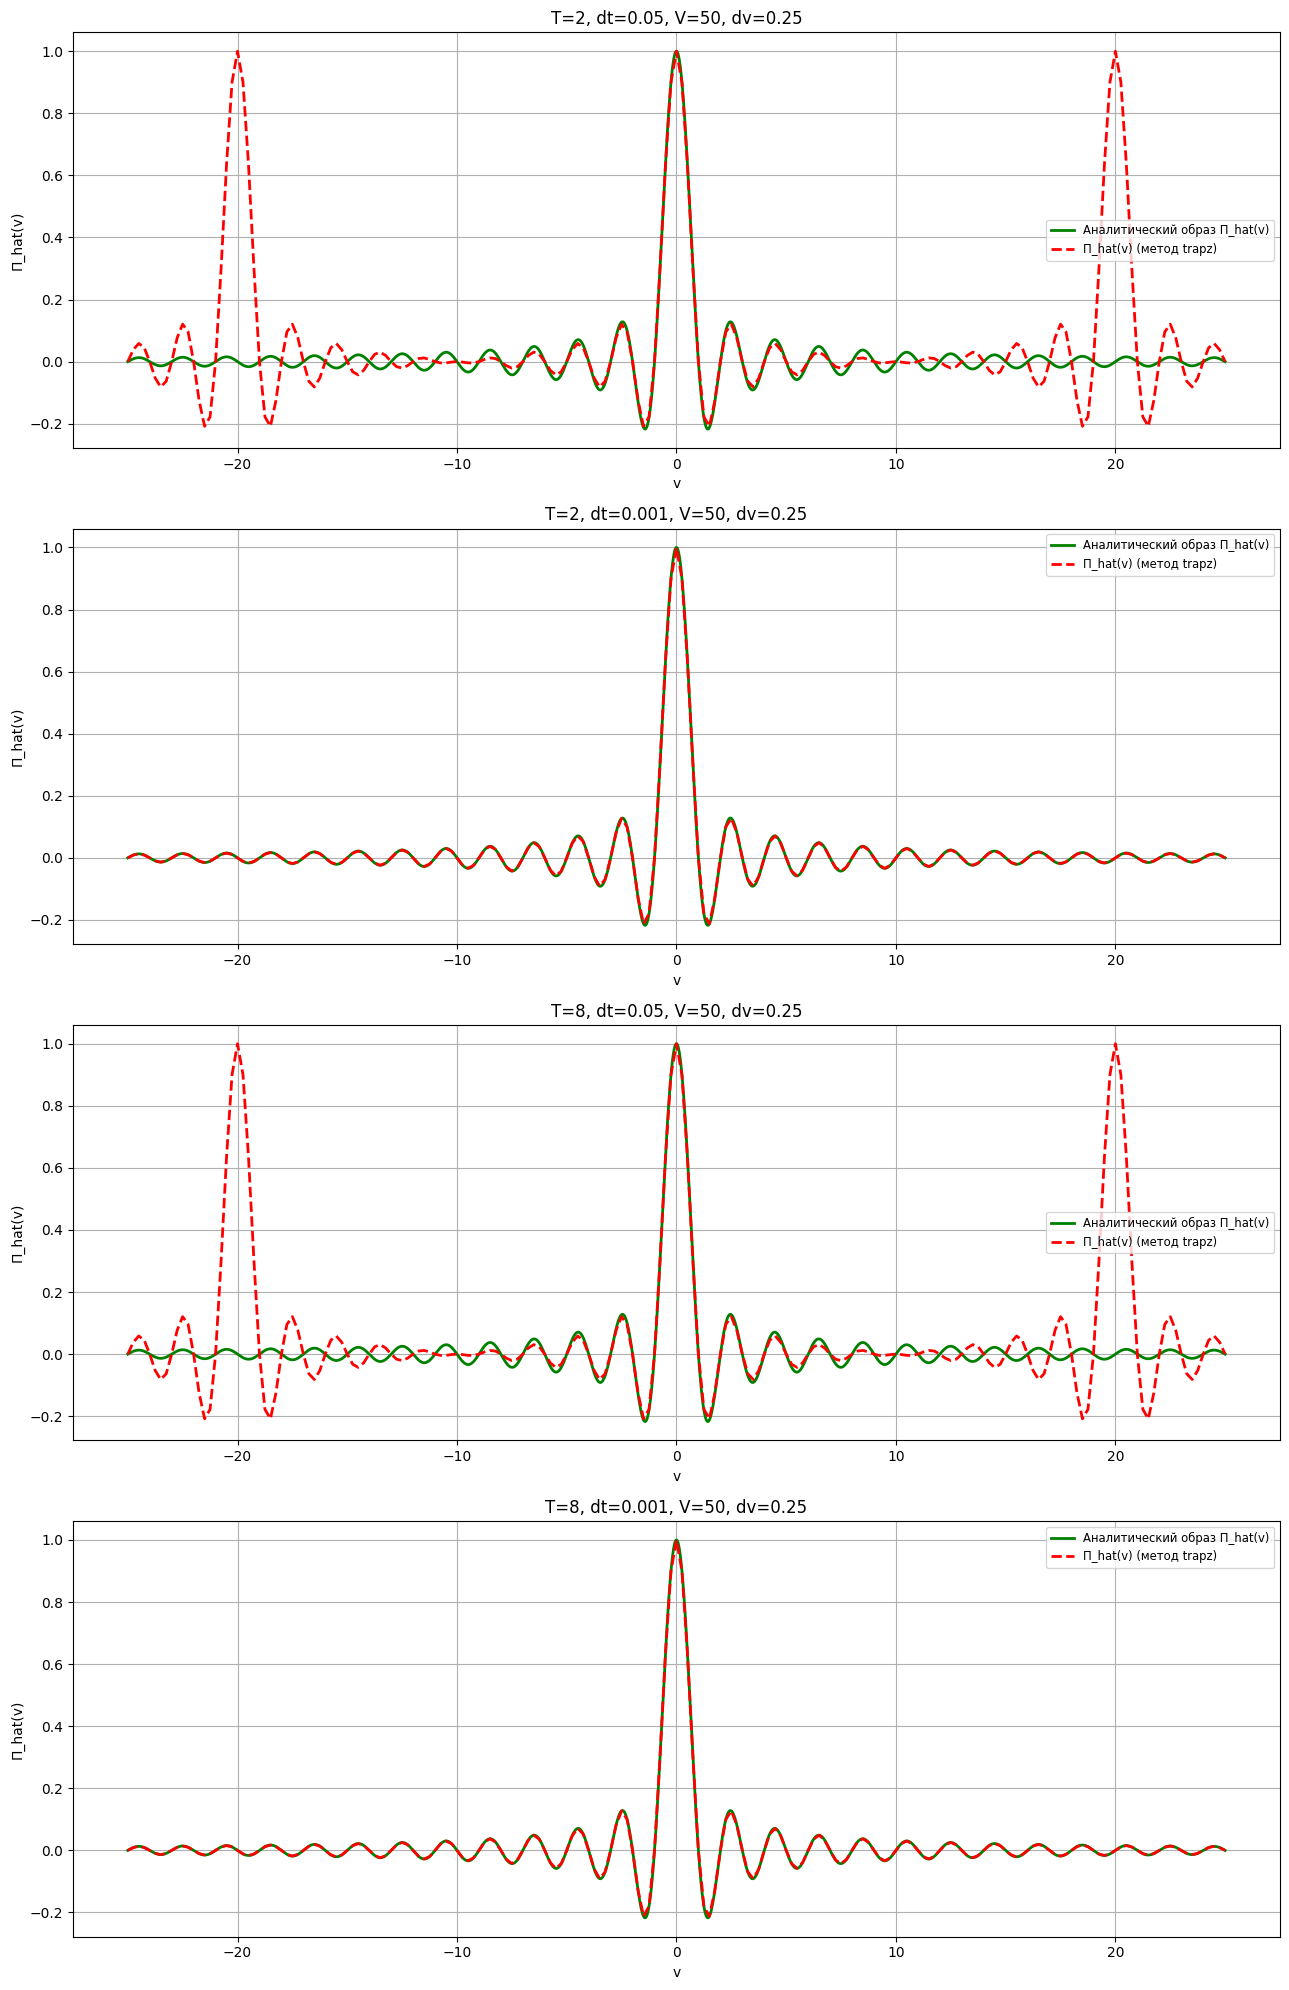

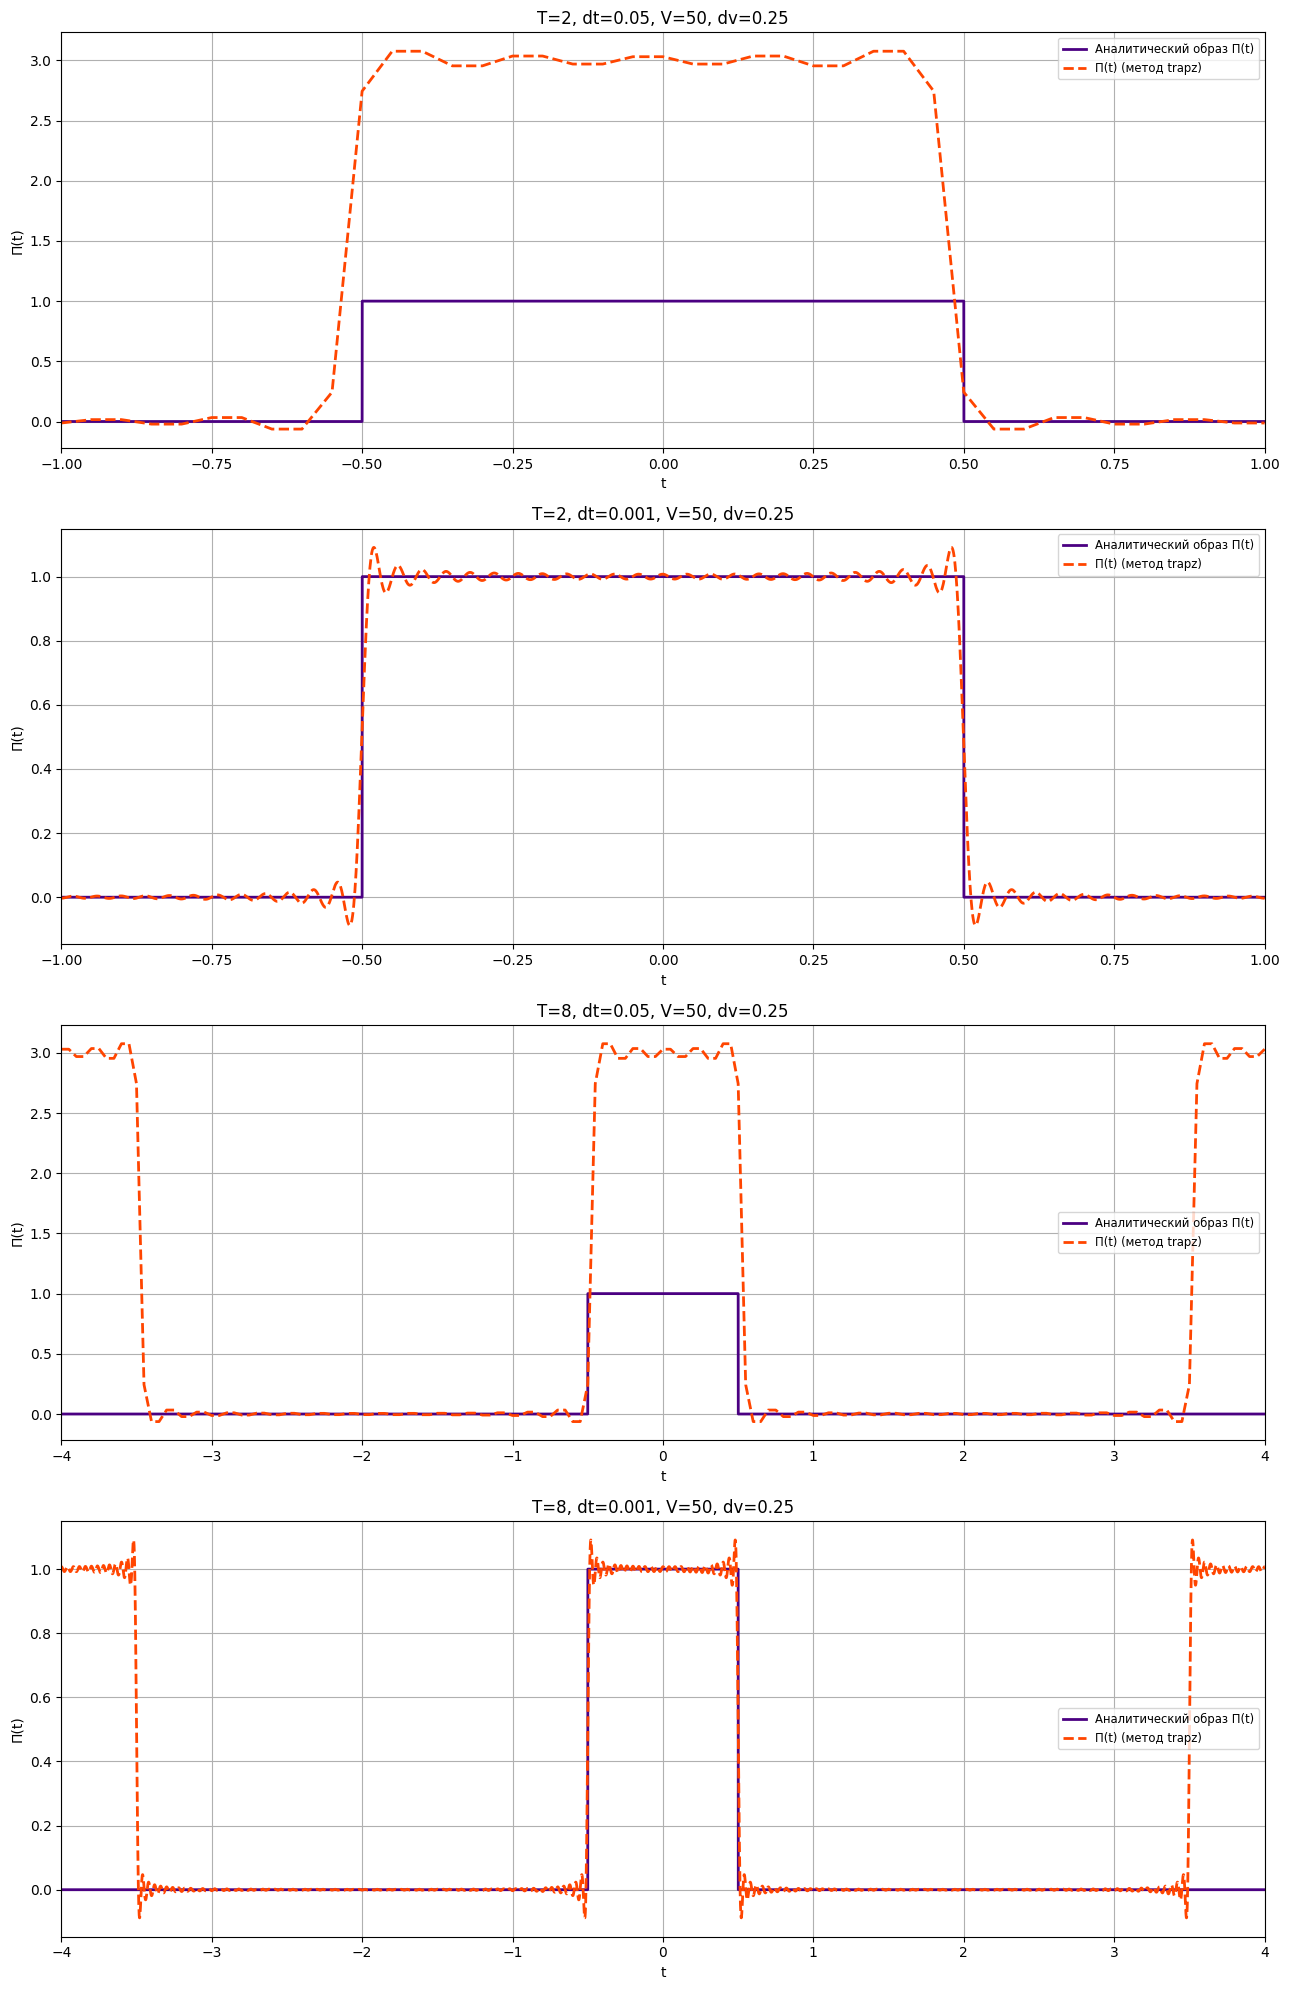

In [7]:
def point_ft(func, t, v):
    return func(t) * np.exp(-2j * np.pi * v * t)
def point_ift(func, v, t):
    return func(v) * np.exp(2j * np.pi * v * t)

T_list = [2, 8]
dt_list = [0.05, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for T in T_list:
    for dt in dt_list:
        V = 50
        dv = 0.25
        t_space = np.arange(-T/2, T/2 + dt, dt)
        v_space = np.arange(-V/2, V/2 + dv, dv)
        PI_hat_trapz = [np.trapz(point_ft(rect_func, t_space, v), t_space) for v in v_space]
        @list_func
        def PI_hat_trapz_f(v):
            global v_space
            return PI_hat_trapz[np.where(v_space==v)[0][0]]
        PI_trapz = [np.trapz(point_ift(PI_hat_trapz_f, v_space, t), v_space) for t in t_space]

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="v", y_label="П_hat(v)", legend=True)
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="t", y_label="П(t)", xlim=(-T/2, T/2), legend=True)
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=2))
        plt_g_V.add_plot(Plot(v_space, PI_hat_trapz, "П_hat(v) (метод trapz)", "red", linewidth=2, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, PI_trapz, "П(t) (метод trapz)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fix_v", dpi=700)
chart_T.save_chart(plt_folder, "П(t)_comparison_fix_v", dpi=700)

del chart_V, chart_T

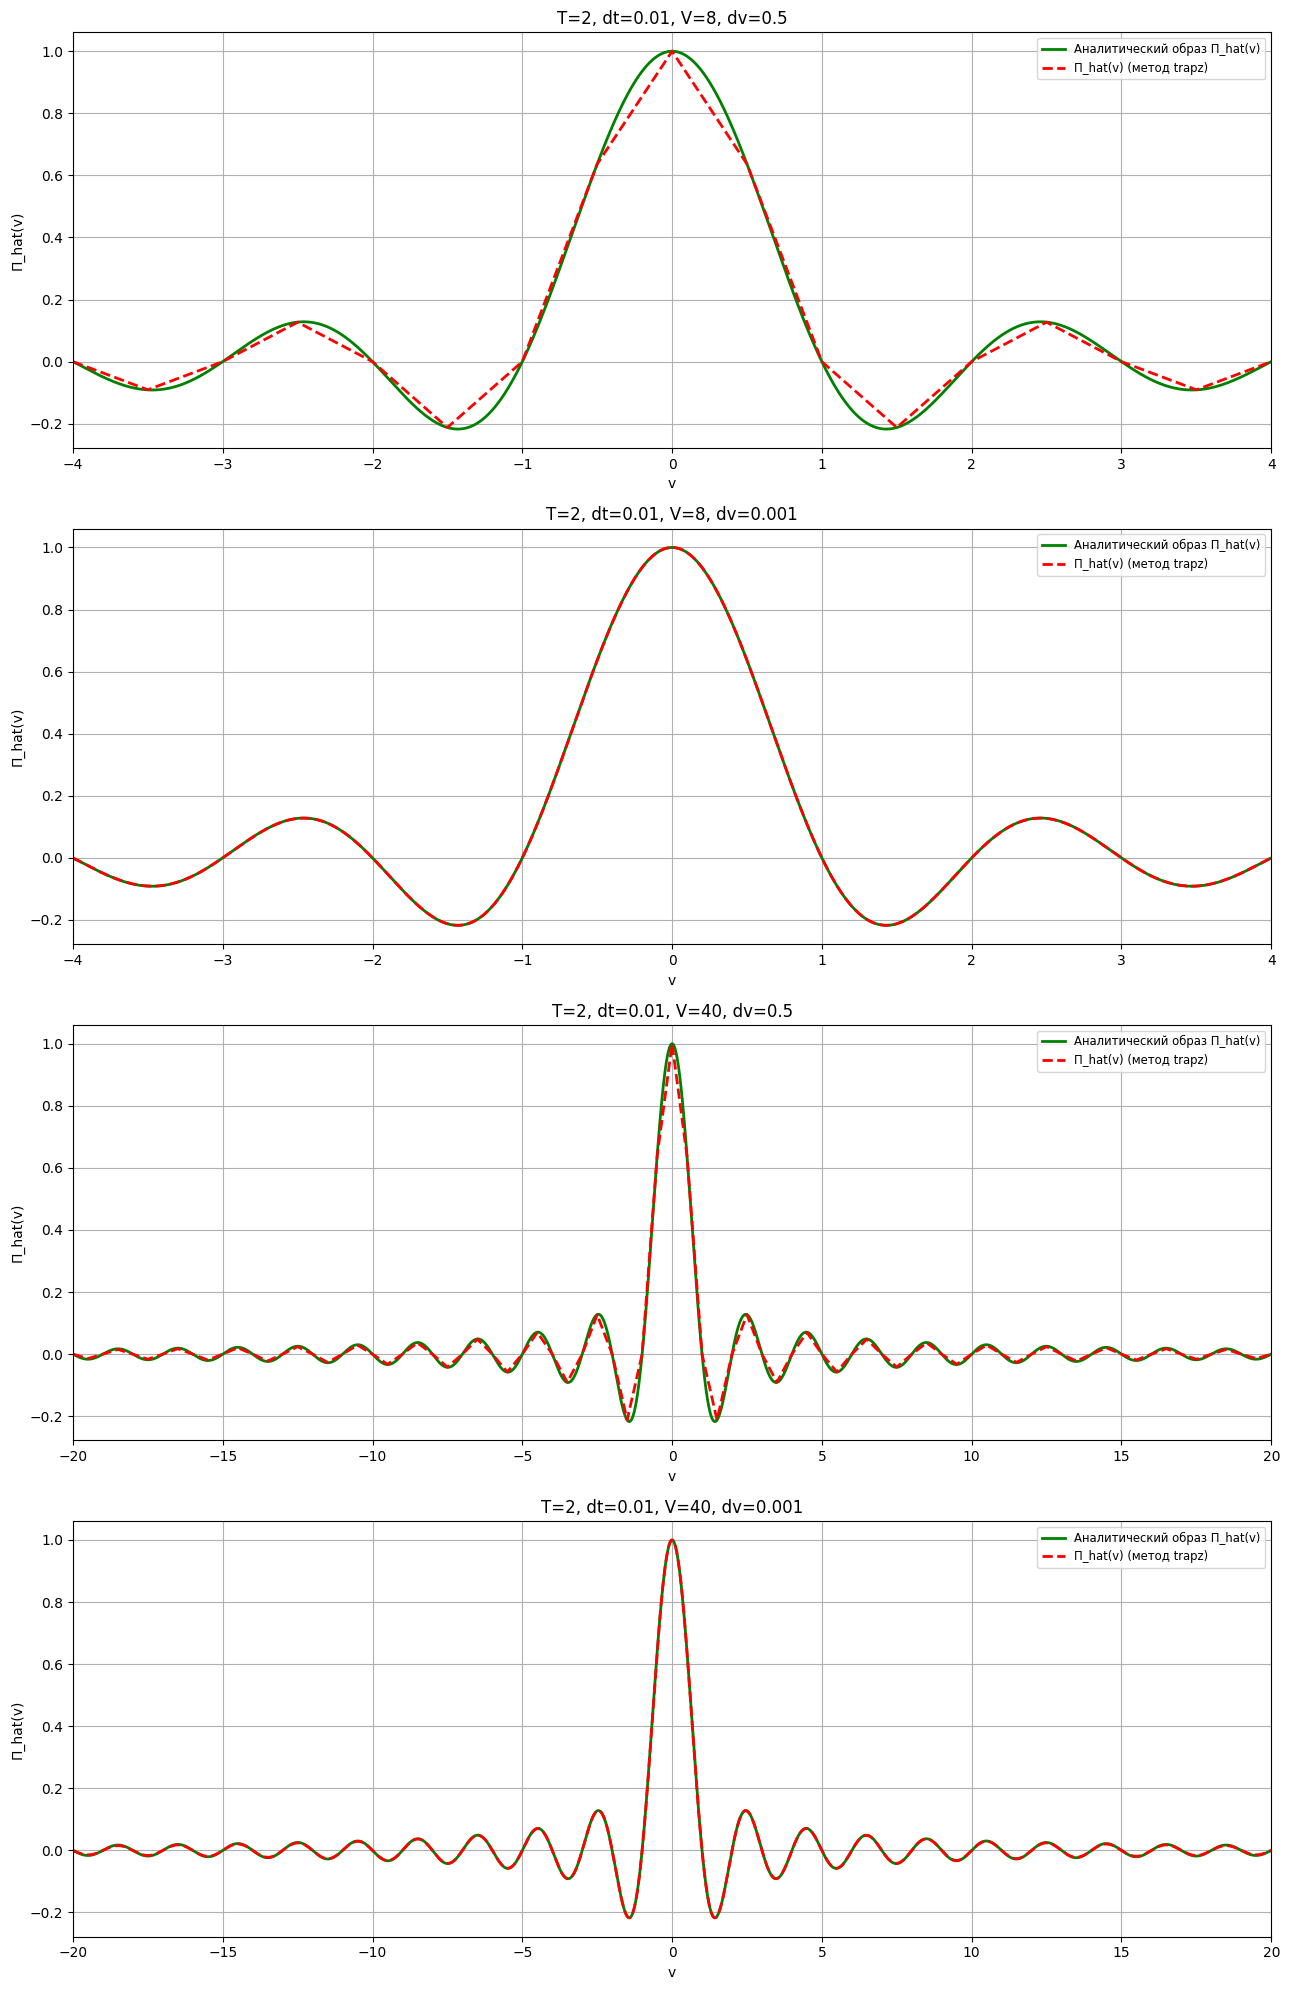

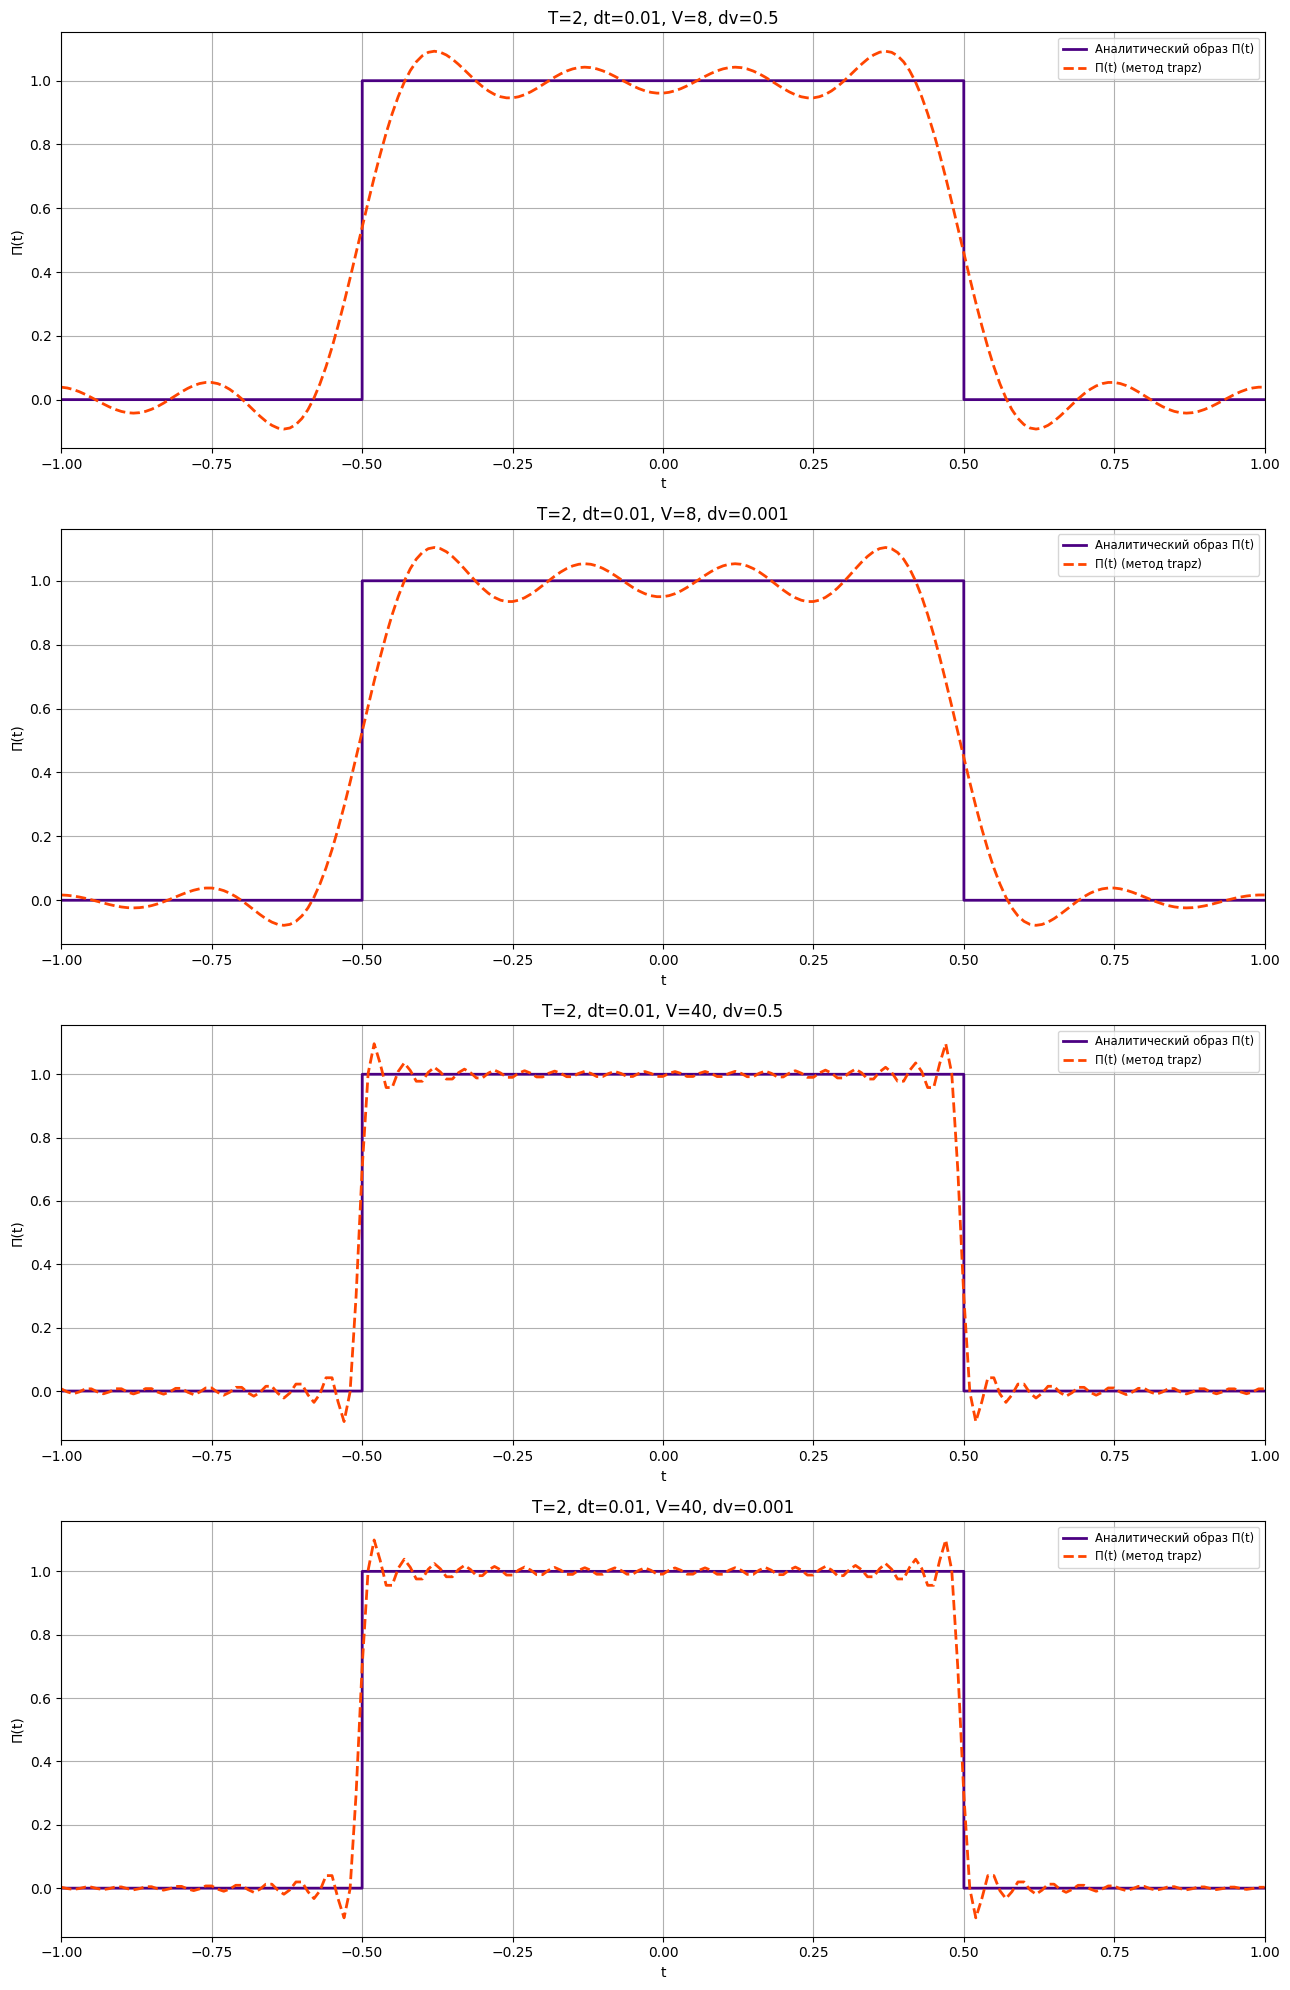

In [8]:
V_list = [8, 40]
dv_list = [0.5, 0.001]

chart_V = Chart(4, 1, 13, 20)
chart_T = Chart(4, 1, 13, 20)

for V in V_list:
    for dv in dv_list:
        T = 2
        dt = 0.01
        t_space = np.arange(-T/2, T/2 + dt, dt)
        v_space = np.arange(-V/2, V/2 + dv, dv)
        PI_hat_trapz = [np.trapz(point_ft(rect_func, t_space, v), t_space) for v in v_space]
        @list_func
        def PI_hat_trapz_f(v):
            global v_space
            return PI_hat_trapz[np.where(v_space==v)[0][0]]
        PI_trapz = [np.trapz(point_ift(PI_hat_trapz_f, v_space, t), v_space) for t in t_space]

        plt_g_V = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="v", y_label="П_hat(v)", xlim=(-V/2, V/2), legend=True)
        plt_g_T = Plot_Group(title=f"T={T}, dt={dt}, V={V}, dv={dv}", x_label="t", y_label="П(t)", xlim=(-1, 1), legend=True)
        plt_g_V.add_plot(Plot(v_rect, PI_hat, "Аналитический образ П_hat(v)", "green", linewidth=2))
        plt_g_V.add_plot(Plot(v_space, PI_hat_trapz, "П_hat(v) (метод trapz)", "red", linewidth=2, linestyle='--'))
        plt_g_T.add_plot(Plot(t_rect, PI, "Аналитический образ П(t)", "indigo", linewidth=2))
        plt_g_T.add_plot(Plot(t_space, PI_trapz, "П(t) (метод trapz)", "orangered", linewidth=2, linestyle='--'))

        chart_V.add_plot_group(plt_g_V)
        chart_T.add_plot_group(plt_g_T)
        del plt_g_V, plt_g_T

chart_V.save_chart(plt_folder, "П_hat(v)_comparison_fix_t", dpi=700)
chart_T.save_chart(plt_folder, "П(t)_comparison_fix_t", dpi=700)

del chart_V, chart_T

# Задание 1.2